## Salary Prediction

In [771]:
# Note:
# Salary prediction is influenced by multiple complex factors such as experience,
# education, and job role. Since relationships may not be fully linear,
# Linear Regression may not capture all patterns and is used here mainly as a baseline model.

In [772]:
import joblib
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import  OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error


In [773]:
df=pd.read_csv('./data/salary.csv')
df.head(5)

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [774]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6704 entries, 0 to 6703
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  6702 non-null   float64
 1   Gender               6702 non-null   str    
 2   Education Level      6701 non-null   str    
 3   Job Title            6702 non-null   str    
 4   Years of Experience  6701 non-null   float64
 5   Salary               6699 non-null   float64
dtypes: float64(3), str(3)
memory usage: 314.4 KB


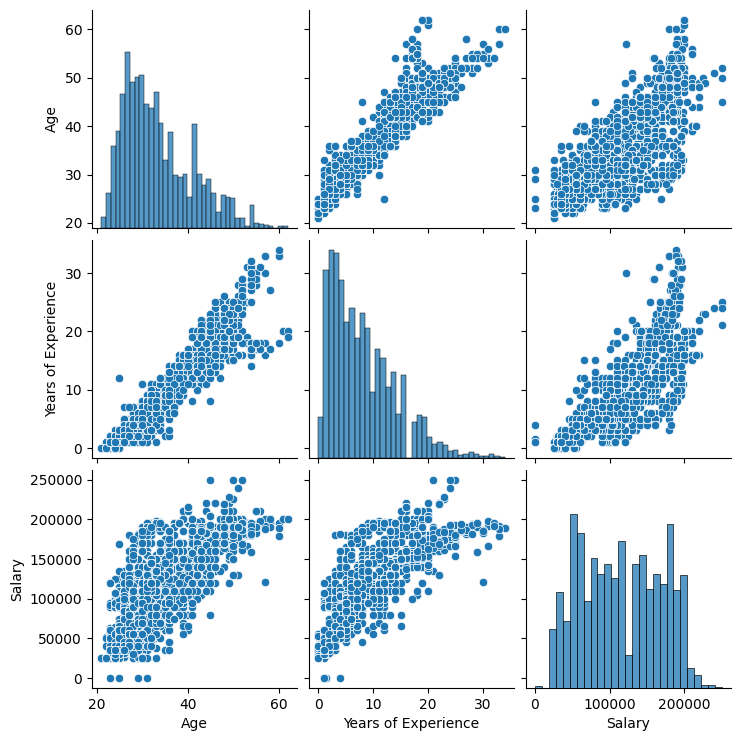

In [775]:
#Visualize the data to understand the relationships between features and the target variable
sns.pairplot(df)
plt.show()

### Feature Engineering

In [776]:
#Check for missing values
print(df.isnull().sum())

Age                    2
Gender                 2
Education Level        3
Job Title              2
Years of Experience    3
Salary                 5
dtype: int64


In [777]:
#In case of Gender, Education and Job Title we will fill missing values with the mode
df['Gender']=df['Gender'].fillna(df['Gender'].mode()[0])
df['Education Level']=df['Education Level'].fillna(df['Education Level'].mode()[0])
df['Job Title']=df['Job Title'].fillna(df['Job Title'].mode()[0])


In [778]:
#For age, experience and salary we will fill missing values with the median as it is less affected by outliers
df['Age']=df['Age'].fillna(df['Age'].median())
df['Years of Experience']=df['Years of Experience'].fillna(df['Years of Experience'].median())
df['Salary']=df['Salary'].fillna(df['Salary'].median()) 

In [779]:
df.isna().sum()

Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64

In [780]:
df.head(5)

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [781]:
#Encoding categorical variables using OneHotEncoder
gender_encoder=OneHotEncoder()
job_encoder=OneHotEncoder()


In [782]:
#Encode the gender column
gender_encoded=gender_encoder.fit_transform(df[['Gender']]).toarray()
gender_df=pd.DataFrame(gender_encoded, columns=gender_encoder.get_feature_names_out(['Gender']),index=df.index) 
df=pd.concat([df, gender_df], axis=1)
df.drop('Gender', axis=1, inplace=True)
df.head(5)

,Age,Education Level,Job Title,Years of Experience,Salary,Gender_Female,Gender_Male,Gender_Other
0,32.0,Bachelor's,Software Engineer,5.0,90000.0,0.0,1.0,0.0
1,28.0,Master's,Data Analyst,3.0,65000.0,1.0,0.0,0.0
2,45.0,PhD,Senior Manager,15.0,150000.0,0.0,1.0,0.0
3,36.0,Bachelor's,Sales Associate,7.0,60000.0,1.0,0.0,0.0
4,52.0,Master's,Director,20.0,200000.0,0.0,1.0,0.0


In [783]:
#Encode the education level column
# Since it is ordinal we will use label encoding instead of one hot encoding

df['Education Level'].value_counts()

Education Level
Bachelor's Degree    2270
Master's Degree      1573
PhD                  1368
Bachelor's            756
High School           448
Master's              288
phD                     1
Name: count, dtype: int64

In [784]:
df["Education Level"] = df["Education Level"].str.strip().str.lower()

df["Education Level"] = df["Education Level"].replace({
    "bachelor's": "bachelor",
    "bachelor's degree": "bachelor",
    "master's": "master",
    "master's degree": "master",
    "phd": "phd",
    "high school": "high school"
})
df["Education Level"].value_counts()

Education Level
bachelor       3026
master         1861
phd            1369
high school     448
Name: count, dtype: int64

In [785]:
education_mapping={'high school':0, 'bachelor':1, 'master':2, 'phd':3}
df['Education Level']=df['Education Level'].map(education_mapping)
df.head(5)

,Age,Education Level,Job Title,Years of Experience,Salary,Gender_Female,Gender_Male,Gender_Other
0,32.0,1,Software Engineer,5.0,90000.0,0.0,1.0,0.0
1,28.0,2,Data Analyst,3.0,65000.0,1.0,0.0,0.0
2,45.0,3,Senior Manager,15.0,150000.0,0.0,1.0,0.0
3,36.0,1,Sales Associate,7.0,60000.0,1.0,0.0,0.0
4,52.0,2,Director,20.0,200000.0,0.0,1.0,0.0


In [786]:
df['Job Title'].value_counts()

Job Title
Software Engineer                520
Data Scientist                   453
Software Engineer Manager        376
Data Analyst                     363
Senior Project Engineer          318
                                ... 
Junior Operations Coordinator      1
Junior Financial Advisor           1
Developer                          1
Social M                           1
Social Media Man                   1
Name: count, Length: 193, dtype: int64

In [787]:
#Create a mapping of job titles to industries
job_map = {
    "Software Engineering": [
        "software", "developer", "frontend", "backend", "full stack", "engineer","software engineer"
    ],
    "Data Science & Analytics": [
        "data scientist", "data analyst", "analytics", "data"
    ],
    "Management": [
        "manager", "director", "lead", "head", "vp"
    ],
    "Sales": ["sales","operation", "logistics", "admin"],
    "Marketing": ["marketing"],
    "HR": ["hr", "recruiter", "talent"],
    "Finance": ["finance", "account", "bank", "audit"],
    "Healthcare": ["doctor", "nurse", "medical"],
    "Education": ["teacher", "professor", "educat"],
}

In [788]:
#Since there are many jobs we will try to group them into broader categories based on the job title
def categorize_job_title(job_title):
    job_title = job_title.lower()

    for category, keywords in job_map.items():
        if any(keyword in job_title for keyword in keywords):
            return category

    return "Other"
      
df["Job Title"] = df["Job Title"].apply(categorize_job_title)
df['Job Title'].value_counts()

Job Title
Software Engineering        2665
Management                  1765
Data Science & Analytics     965
Other                        474
Sales                        348
Marketing                    336
HR                           144
Finance                        7
Name: count, dtype: int64

In [789]:
#Remove the rows with "Other" job title as they are not relevant for our analysis
df=df[df['Job Title']!="Other"]
df['Job Title'].value_counts()


Job Title
Software Engineering        2665
Management                  1765
Data Science & Analytics     965
Sales                        348
Marketing                    336
HR                           144
Finance                        7
Name: count, dtype: int64

In [790]:
#Now we will encode the job title column using one hot encoding
job_encoded=job_encoder.fit_transform(df[['Job Title']]).toarray()
job_df=pd.DataFrame(job_encoded, columns=job_encoder.get_feature_names_out(['Job Title']),index=df.index)
df=pd.concat([df, job_df], axis=1)
df.drop('Job Title', axis=1, inplace=True)
df.head(5)

,Age,Education Level,Years of Experience,Salary,Gender_Female,Gender_Male,Gender_Other,Job Title_Data Science & Analytics,Job Title_Finance,Job Title_HR,Job Title_Management,Job Title_Marketing,Job Title_Sales,Job Title_Software Engineering
0,32.0,1,5.0,90000.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,28.0,2,3.0,65000.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,45.0,3,15.0,150000.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,36.0,1,7.0,60000.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,52.0,2,20.0,200000.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [791]:

df.isna().sum()

Age                                   0
Education Level                       0
Years of Experience                   0
Salary                                0
Gender_Female                         0
Gender_Male                           0
Gender_Other                          0
Job Title_Data Science & Analytics    0
Job Title_Finance                     0
Job Title_HR                          0
Job Title_Management                  0
Job Title_Marketing                   0
Job Title_Sales                       0
Job Title_Software Engineering        0
dtype: int64

In [792]:
df.info()

<class 'pandas.DataFrame'>
Index: 6230 entries, 0 to 6703
Data columns (total 14 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Age                                 6230 non-null   float64
 1   Education Level                     6230 non-null   int64  
 2   Years of Experience                 6230 non-null   float64
 3   Salary                              6230 non-null   float64
 4   Gender_Female                       6230 non-null   float64
 5   Gender_Male                         6230 non-null   float64
 6   Gender_Other                        6230 non-null   float64
 7   Job Title_Data Science & Analytics  6230 non-null   float64
 8   Job Title_Finance                   6230 non-null   float64
 9   Job Title_HR                        6230 non-null   float64
 10  Job Title_Management                6230 non-null   float64
 11  Job Title_Marketing                 6230 non-null   float64

In [793]:
df['Age'] = df['Age'].astype(int)


## Training the model

In [794]:
#Split the data into features and target variable
X=df.drop('Salary', axis=1)
y=df['Salary']

In [795]:
#Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape) 

Training set size: (4984, 13)
Testing set size: (1246, 13)


In [796]:
#No need to standardize the features as we they are not high

In [797]:
model= LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [798]:
print(f'Coefficient (slope): {model.coef_}')
print(f'Intercept: {model.intercept_}')

Coefficient (slope): [  -905.71686363   7745.43975895   6732.10538128   6250.25381542
   9097.66415794 -15347.91797336  35794.00781566 -22269.83809877
 -17398.18555914  12939.990425    -5766.45390073 -19145.85945935
  15846.33877733]
Intercept: 57938.36244707076


In [799]:
y_pred = model.predict(X_test)

Text(0.5, 1.0, 'Actual vs Predicted (colored by error)')

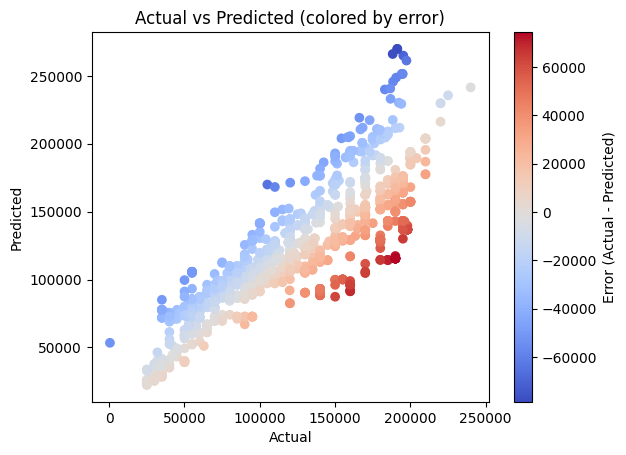

In [800]:
errors = y_test - y_pred

plt.scatter(y_test, y_pred, c=errors, cmap='coolwarm')
plt.colorbar(label="Error (Actual - Predicted)")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted (colored by error)")

In [801]:
mse=mean_squared_error(y_test, y_pred)
r2=r2_score(y_test, y_pred)
mae=mean_absolute_error(y_test, y_pred)
rmse=np.sqrt(mse)
print(f'Mean Squared Error: {mse:.2f}')
print(f'R-squared: {r2:.2f}')
print(f'Mean Absolute Error: {mae:.2f}')
print(f'Root Mean Squared Error: {rmse:.2f}')

Mean Squared Error: 693398207.17
R-squared: 0.75
Mean Absolute Error: 20448.05
Root Mean Squared Error: 26332.46


In [802]:
joblib.dump(model, 'salary_prediction_model.pkl')

['salary_prediction_model.pkl']